In [1]:
import math
import numpy as np
import pandas as pd
import networkx as nx
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as colors
from github_helper import from_github
from itertools import combinations

## 2.1) Network Type
In understanding the type of network we are working with, we first investigate what distributions best fit our model, the effects of thresholding, and then the implications for the temporality of the network.

### 2.1.1) Degree Distribution
We first wish to compare the degree distribution of our network to known degree distributions. To approximate the "true" distribution of the network, we get the degree distributions across all periods for "immigration" and "general". We calculate them under different thresholds and then fit Power-Law, Log-Normal, Exponential and Poisson distributions to the degree distributions, and analyze which, if any, distribution best fits the distribution of the network.

In [2]:
def make_specific_graph(topic_df, period, threshold=0.7):
    """Builds a graph for a single period at a given threshold from a preloaded topic_df."""
    specific_df = topic_df[topic_df['Period'] == period]
    thresh_df = specific_df[specific_df['weight'] >= threshold]
    if thresh_df.empty:
        return nx.Graph()  # empty
    G = nx.from_pandas_edgelist(thresh_df, source='source', target='target', edge_attr='weight')
    return G

def degrees_across_periods(topic="general", agg_level="politician", period_level="Period",
                           threshold=0.7, periods=None):
    """
    Returns a long DataFrame with columns: ['Period','node','degree']
    One row per (node, period) when the node appears in the thresholded graph.
    """
    # Load once
    topic_df = pd.read_csv(from_github(f"/edges/{agg_level}/{period_level}/{agg_level}_edges_{topic}_by_{period_level}.csv"))

    # Pick periods to include
    if periods is None:
        periods = sorted(topic_df[period_level].unique().tolist())
    else:
        periods = [p for p in periods if p in set(topic_df[period_level].unique())]

    rows = []
    for p in periods:
        G = make_specific_graph(topic_df.rename(columns={period_level: 'Period'}), period=p, threshold=threshold)
        if len(G) == 0:
            continue
        for node, deg in G.degree():
            rows.append((p, node, deg))

    df_deg = pd.DataFrame(rows, columns=['Period', 'node', 'degree'])
    return df_deg

In [3]:
def fit_and_plot_logbinned_combined(
    df_deg,
    periods=(66, 67, 68, 69, 70, 71),
    ax=None,
    num_bins=20,
    threshold=0.7,
    topic="general"
):
    """
    Computes the combined degree distribution across all given periods
    and plots:
      - Black log-binned data points (no connecting lines)
      - Fitted model curves (Power-law, Log-normal, Exponential, Poisson)
        each colored from the Viridis colormap.
    Returns the Matplotlib axis (ax).
    """

    # --- Collect degree data across all periods ---
    combined = df_deg.loc[df_deg['Period'].isin(periods), 'degree'].astype(int)
    combined = combined[combined > 0].to_numpy()

    if combined.size == 0:
        print("No valid degree data found for the selected periods.")
        return ax

    n = combined.size
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    # --- Log-binning setup ---
    dmin, dmax = max(1, int(combined.min())), int(combined.max())
    if dmin == dmax:
        dmin = max(1, dmin - 1)
        dmax = dmax + 1
    bins = np.logspace(np.log10(dmin), np.log10(dmax), num_bins)
    counts, _ = np.histogram(combined, bins=bins)
    bin_centers = np.sqrt(bins[:-1] * bins[1:])
    pos = counts > 0

    # --- Empirical CDF for KS tests ---
    empirical_cdf_x = np.sort(combined)
    empirical_cdf_y = np.arange(1, n + 1) / n

    # --- Prepare Viridis colors for model fits ---
    cmap = plt.cm.viridis
    colors = {
        "powerlaw": cmap(0.2),
        "lognorm": cmap(0.4),
        "expon": cmap(0.6),
        "poisson": cmap(0.8)
    }

    # --- Plot log-binned empirical data (black dots, no connecting lines) ---
    ax.scatter(bin_centers[pos], counts[pos], s=18, color='black', alpha=0.8, label='Log-binned data')

    # ==========================
    #        Model fits
    # ==========================

    # --- Power-law ---
    log_x = np.log(bin_centers[pos])
    log_y = np.log(counts[pos])
    coeffs = np.polyfit(log_x, log_y, 1)
    alpha = -coeffs[0]
    intercept = np.exp(coeffs[1])
    powerlaw_y = intercept * bin_centers ** (-alpha)
    xmin = combined.min()
    cdf_powerlaw = 1 - (xmin / empirical_cdf_x) ** (alpha - 1)
    ks_powerlaw = np.max(np.abs(empirical_cdf_y - cdf_powerlaw))
    ax.plot(bin_centers, powerlaw_y, lw=2.0, color=colors["powerlaw"],
            label=f'Power-law (α={alpha:.2f}, KS={ks_powerlaw:.2f})')

    # --- Log-normal ---
    shape, loc, scale = stats.lognorm.fit(combined, floc=0)
    lognorm_x = np.linspace(1, combined.max(), 200)
    lognorm_pdf = stats.lognorm.pdf(lognorm_x, shape, loc, scale)
    lognorm_y = lognorm_pdf * counts.max() / lognorm_pdf.max()
    ks_lognorm = stats.kstest(combined, 'lognorm', args=(shape, loc, scale)).statistic
    ax.plot(lognorm_x, lognorm_y, lw=2.0, color=colors["lognorm"],
            label=f'Log-normal (KS={ks_lognorm:.2f})')

    # --- Exponential ---
    exp_params = stats.expon.fit(combined)
    exp_x = np.linspace(1, combined.max(), 200)
    exp_pdf = stats.expon.pdf(exp_x, *exp_params)
    exp_y = exp_pdf * counts.max() / exp_pdf.max()
    ks_exp = stats.kstest(combined, 'expon', args=exp_params).statistic
    ax.plot(exp_x, exp_y, lw=2.0, color=colors["expon"],
            label=f'Exponential (KS={ks_exp:.2f})')

    # --- Poisson (truncated) ---
    lam = combined.mean()
    p0 = stats.poisson.pmf(0, mu=lam)
    k_vals = np.arange(1, max(2, combined.max()) + 1)
    pois_pmf = stats.poisson.pmf(k_vals, mu=lam)
    pois_pmf_trunc = pois_pmf / max((1 - p0), 1e-12)
    pois_y = pois_pmf_trunc * counts.max() / pois_pmf_trunc.max()
    cdf_po_trunc = (stats.poisson.cdf(empirical_cdf_x, mu=lam) - p0) / max((1 - p0), 1e-12)
    ks_pois = np.max(np.abs(empirical_cdf_y - cdf_po_trunc))
    ax.plot(k_vals, pois_y, lw=2.0, color=colors["poisson"],
            label=f'Poisson (KS={ks_pois:.2f})')

    # --- Formatting ---
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Degree (log)')
    ax.set_ylabel('Number of nodes (log)')
    ax.legend(fontsize=8, ncol=2)
    ax.set_ylim(bottom=0.8, top = 1000)
    ax.set_xlim(left=5)
    ax.set_title(f'Total degree distribution across all periods\nThreshold = {threshold:.0%}, Topic = {topic}')

    return ax


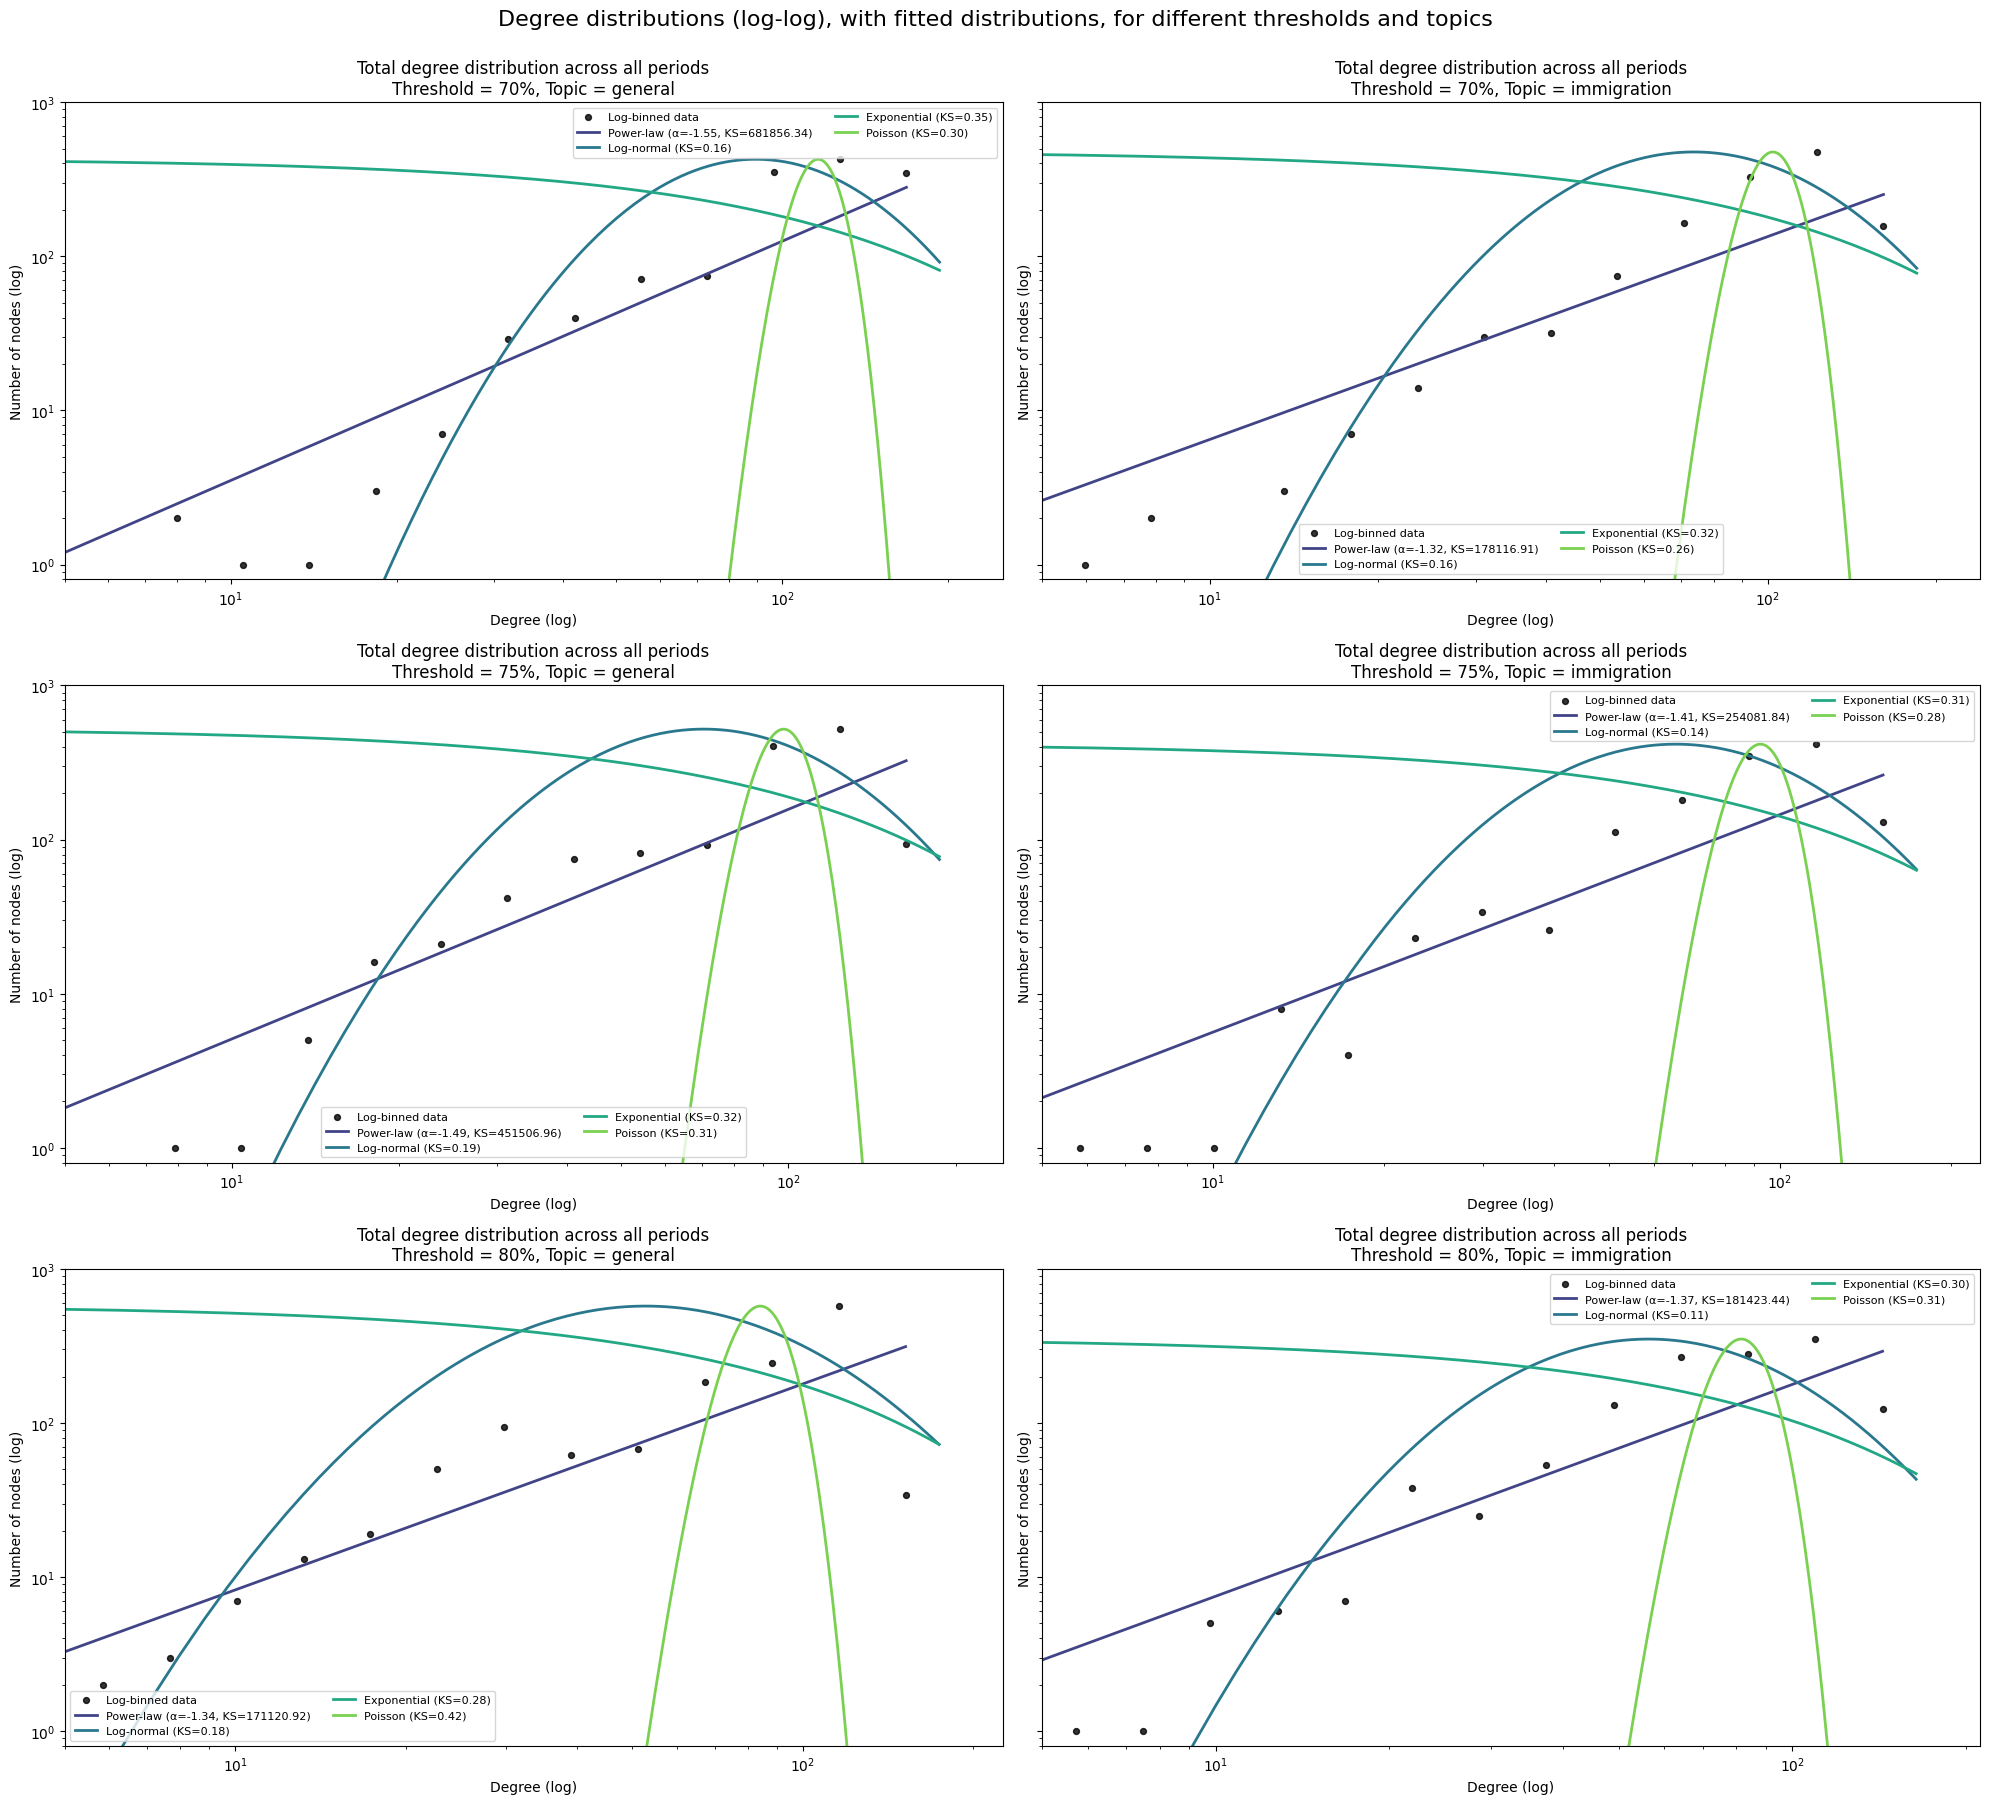

In [4]:
selected_topic = "general"
other_topic = "immigration"
df_deg_gen_70 = degrees_across_periods(topic=selected_topic, threshold=0.7)
df_deg_gen_75 = degrees_across_periods(topic=selected_topic, threshold=0.75)
df_deg_gen_80 = degrees_across_periods(topic=selected_topic, threshold=0.8)
df_deg_other_70 = degrees_across_periods(topic=other_topic, threshold=0.7)
df_deg_other_75 = degrees_across_periods(topic=other_topic, threshold=0.75)
df_deg_other_80 = degrees_across_periods(topic=other_topic, threshold=0.8)

fig, axs = plt.subplots(3, 2, figsize=(20, 18), sharey=True)
plt.suptitle(f"Degree distributions (log-log), with fitted distributions, for different thresholds and topics", fontsize = 16, y = 1.0)
periods = (66,67,68,69,70,71)
n_bins = 20

fit_and_plot_logbinned_combined(df_deg_gen_70, periods=periods, num_bins=n_bins, ax = axs[0,0], threshold=0.70, topic = selected_topic)
fit_and_plot_logbinned_combined(df_deg_gen_75, periods=periods, num_bins=n_bins, ax = axs[1,0], threshold=0.75, topic = selected_topic)
fit_and_plot_logbinned_combined(df_deg_gen_80, periods=periods, num_bins=n_bins, ax = axs[2,0], threshold=0.80, topic = selected_topic)

fit_and_plot_logbinned_combined(df_deg_other_70, periods=periods, num_bins=n_bins, ax = axs[0,1], threshold=0.70, topic = other_topic)
fit_and_plot_logbinned_combined(df_deg_other_75, periods=periods, num_bins=n_bins, ax = axs[1,1], threshold=0.75, topic = other_topic)
fit_and_plot_logbinned_combined(df_deg_other_80, periods=periods, num_bins=n_bins, ax = axs[2,1], threshold=0.80, topic = other_topic)


plt.tight_layout()
plt.show()


>**Figure X:** The plot shows the distributions of the degrees of the Politician Agreement Network across all periods, for all-votes "general" and for "immigration", aross 3 different thresholding values. It is compared to the PDF of 4 different distributions, a Power-law Distribution, a Log-Normal Distribution, an Exponential Distribution and a Poisson Distribution. The log-normal distribution consistently provides the best fit.

# DO NOT COPY IN THE BELOW BLOCK, IT IS FOR REPORT

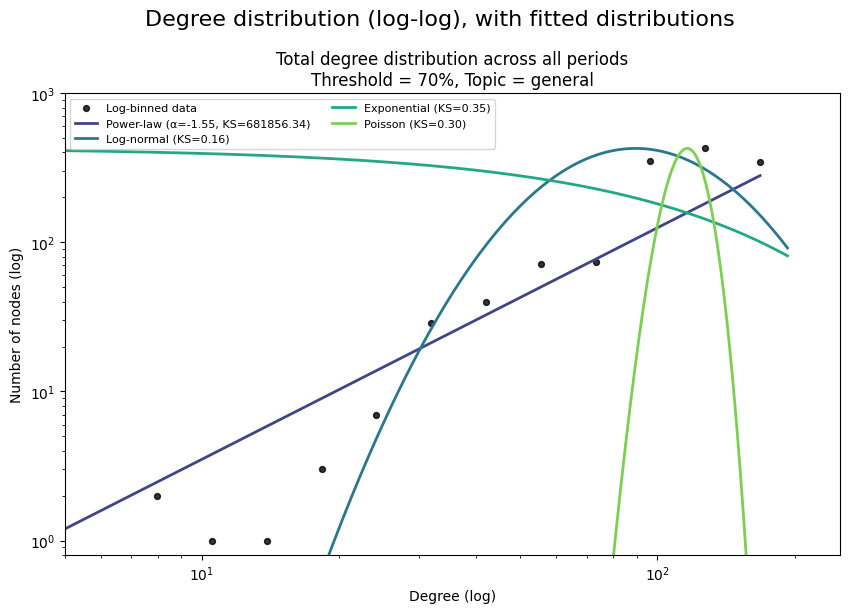

In [17]:
## THIS IS JUST FOR INSERTING INTO THE REPORT

selected_topic = "general"
df_deg_gen_70 = degrees_across_periods(topic=selected_topic, threshold=0.7)


fig, axs = plt.subplots(1, 1, figsize=(10, 6))
# plt.suptitle(f"Degree distributions (log-log), with fitted distributions, for different thresholds and topics", fontsize = 16, y = 1.0)
plt.suptitle(f"Degree distribution (log-log), with fitted distributions", fontsize = 16, y = 1.02)
periods = (66,67,68,69,70,71)
n_bins = 20

fit_and_plot_logbinned_combined(df_deg_gen_70, periods=periods, num_bins=n_bins, ax = axs, threshold=0.70, topic = selected_topic)
plt.suptitle
plt.show()

### 2.1.2) Temporal edges and thresholding
As concluded by the graph above, the best thresholding fit, depends on the topic. Across all topics it is however a threshold of 70% (lower threshold were tested and provided worse fits), that fits best, and it is therefore the threshold we will use going forward.  
Now we investigate the tempral nature of the network, and try and get an understanding of the implications of thresholding. 

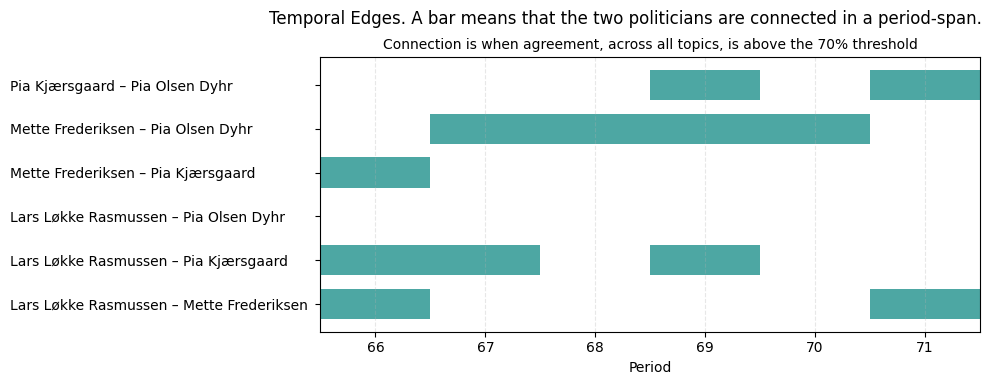

In [5]:
politicians = ["Pia Kjærsgaard", "Lars Løkke Rasmussen", "Mette Frederiksen", "Pia Olsen Dyhr"]
topic = "general"

def get_df_for_some_politicians(politicians, topic):
    # df_1 = pd.read_csv(from_github(f"/edges/politician/Period/politician_edges_{two_topics[0]}_by_Period.csv"))
    # df_2 = pd.read_csv(from_github(f"/edges/politician/Period/politician_edges_{two_topics[1]}_by_Period.csv"))
    # df = pd.concat([df_1, df_2])
    df = pd.read_csv(from_github(f"/edges/politician/Period/politician_edges_{topic}_by_Period.csv"))
    df = df[(df['source'].isin(politicians)) & (df['target'].isin(politicians))]
    return df

simple_df = get_df_for_some_politicians(politicians, topic)

def plot_simple_temporal_edges(
    simple_df: pd.DataFrame,
    periods=(66, 67, 68, 69, 70, 71),
    threshold=0.7,
    bar_color=None,
    edge_color="black",
    ax=None
):
    """
    Minimal illustrative plot for temporal edges:
      - One row per combination of politicians (pairs)
      - One column per period
      - A bar is drawn only when weight >= threshold
    """
    df = simple_df.copy()

    # --- Detect all politicians ---
    politicians = pd.unique(df[["source", "target"]].values.ravel("K"))
    politicians = np.unique(politicians)
    n_pols = len(politicians)

    if n_pols < 2:
        raise ValueError("Need at least two politicians in the dataframe.")

    # --- Generate all unique pairs ---
    all_pairs = list(combinations(sorted(politicians), 2))
    wanted_labels = [f"{a} – {b}" for a, b in all_pairs]

    # --- Normalize direction (A–B same as B–A) ---
    df["src_norm"] = df[["source", "target"]].min(axis=1)
    df["tgt_norm"] = df[["source", "target"]].max(axis=1)
    df["edge"] = df["src_norm"] + " – " + df["tgt_norm"]

    # --- Filter and aggregate ---
    base = df[(df["edge"].isin(wanted_labels)) & (df["Period"].isin(periods))].copy()
    if base.empty:
        print("No edges found for the selected periods/politicians.")
        return ax

    agg = base.groupby(["edge", "Period"], as_index=False).agg(weight=("weight", "mean"))

    # --- Row positions ---
    edges = wanted_labels
    y_positions = {edge: i for i, edge in enumerate(edges)}

    # --- Prepare plot ---
    if ax is None:
        fig, ax = plt.subplots(figsize=(14, 6))

    # --- Use Viridis midpoint color ---
    if bar_color is None:
        bar_color = plt.cm.viridis(0.5)

    seg = agg[agg["weight"] >= threshold].copy()

    # --- Draw bars ---
    for _, row in seg.sort_values(["edge", "Period"]).iterrows():
        edge = row["edge"]
        period = row["Period"]
        y = y_positions[edge]
        ax.broken_barh(
            [(period - 0.5, 1.0)],
            (y - 0.35, 0.7),
            facecolors=bar_color,
            edgecolors=edge_color,
            alpha = 0.8,
            linewidth=0.6
        )

    # --- Axes formatting ---
    ax.set_yticks(range(len(edges)))
    ax.set_yticklabels(edges, ha="left")
    ax.tick_params(axis="y", pad=220)

    ax.set_xticks(list(periods))
    ax.set_xlim(min(periods) - 0.5, max(periods) + 0.5)
    ax.set_xlabel("Period")
    ax.set_title("Connection is when agreement, across all topics, is above the 70% threshold", fontsize = 10)

    ax.grid(axis="x", linestyle="--", alpha=0.3)

    return ax

fig, axs = plt.subplots(1, 1, figsize=(10, 4), sharey=True)

plot_simple_temporal_edges(simple_df, ax=axs, edge_color = None)
plt.suptitle("Temporal Edges. A bar means that the two politicians are connected in a period-span.", fontsize = 12, x= 0.63, y = 0.95)
plt.tight_layout()
plt.show()


In [6]:
def get_df_for_traditional_parties():
    party_edges = pd.read_csv(from_github(f"/edges/party/all_party_edges_by_Period.csv"))
    traditional_parties = ["Det Konservative Folkeparti", "Enhedslisten", "Liberal Alliance", "Radikale Venstre", "Socialdemokratiet", "Socialistisk Folkeparti", "Venstre", "Dansk Folkeparti"]
    trad_parties = (party_edges['source'].isin(traditional_parties) & party_edges['target'].isin(traditional_parties))
    df_trad = party_edges[trad_parties]
    return df_trad

df_traditional_parties = get_df_for_traditional_parties()

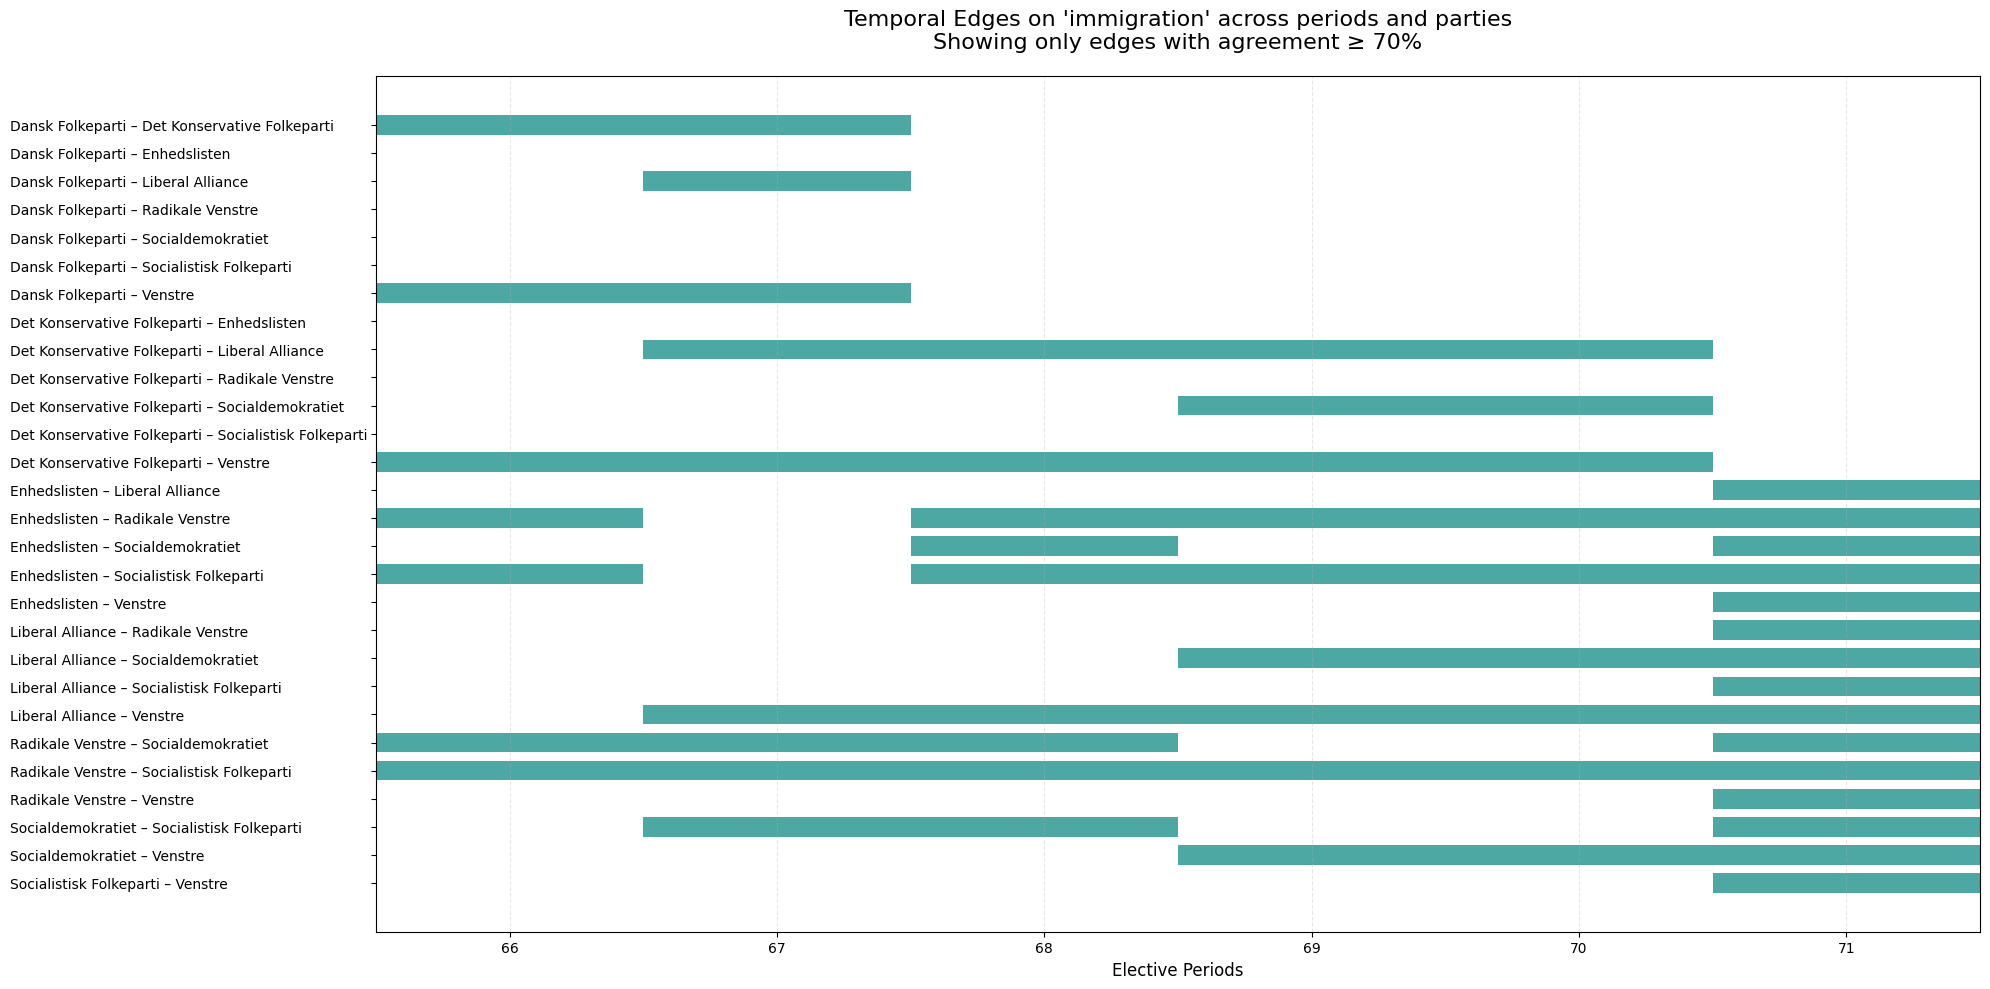

In [7]:
def plot_edge_timeline(
    df_trad,
    topic,
    weight_threshold=0.7,               # now actually used
    periods=(66, 67, 68, 69, 70, 71),
    cmap_name="viridis"
):
    df = df_trad.copy()

    # --- 1) Base filter: topic, periods, no self-edges ---
    base = df[
        (df["topic"] == topic) &
        (df["source"] != df["target"]) &
        (df["Period"].isin(periods))
    ].copy()

    if base.empty:
        print("No edges for this topic/period selection.")
        return

    # --- 2) Build edge label & sort for stable ordering ---
    base["edge"] = base["source"] + " – " + base["target"]
    base = base.sort_values(["source", "target"], ascending=False)

    edges = (base["source"] + " – " + base["target"]).unique().tolist()
    y_positions = {edge: i for i, edge in enumerate(edges)}

    # --- 3) Enforce threshold for drawing ---
    seg = base[base["weight"] >= weight_threshold].copy()

    # --- 4) Single fixed color for all bars ---
    fixed_color = plt.cm.viridis(0.5)   # <- same for all bars

    # --- 5) Plot ---
    fig, ax = plt.subplots(figsize=(20, 10))

    if not seg.empty:
        for _, row in seg.sort_values(["edge", "Period"]).iterrows():
            edge = row["edge"]
            period = row["Period"]
            y = y_positions[edge]

            ax.broken_barh(
                [(period - 0.5, 1.0)],
                (y - 0.35, 0.7),
                facecolors=fixed_color,
                alpha = 0.8,
                edgecolors=None, #"black"
                linewidth=0.4
            )

    # --- 6) Axis formatting ---
    ax.set_yticks(range(len(edges)))
    ax.set_yticklabels(edges, ha="left")
    ax.tick_params(axis='y', pad=260)

    ax.set_xticks(list(periods))
    ax.set_xlim(min(periods) - 0.5, max(periods) + 0.5)

    ax.set_xlabel("Elective Periods", fontsize=12)

    ax.set_title(
        f"Temporal Edges on '{topic}' across periods and parties\n"
        f"Showing only edges with agreement ≥ {int(weight_threshold*100)}%",
        fontsize=16,
        pad=20
    )

    ax.grid(axis="x", linestyle="--", alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_edge_timeline(df_traditional_parties, topic="immigration", weight_threshold=0.7)

>**Figure X:** The plot shows in which periods, party-pairs have had an agreement above 50%, and what interval their agreement lies in. In terms of Network Analysis the existance of an agreement above a certain threshold is interpreted as the duration in which nodes are connected. "Enhedslisten" has only in period 71 had an agreement above 50% regarding immigration with "Liberal Alliance", but they have had more than 50% agreement for all periods with both "Radikale Venstre" and "Socialistisk Folkeparti"

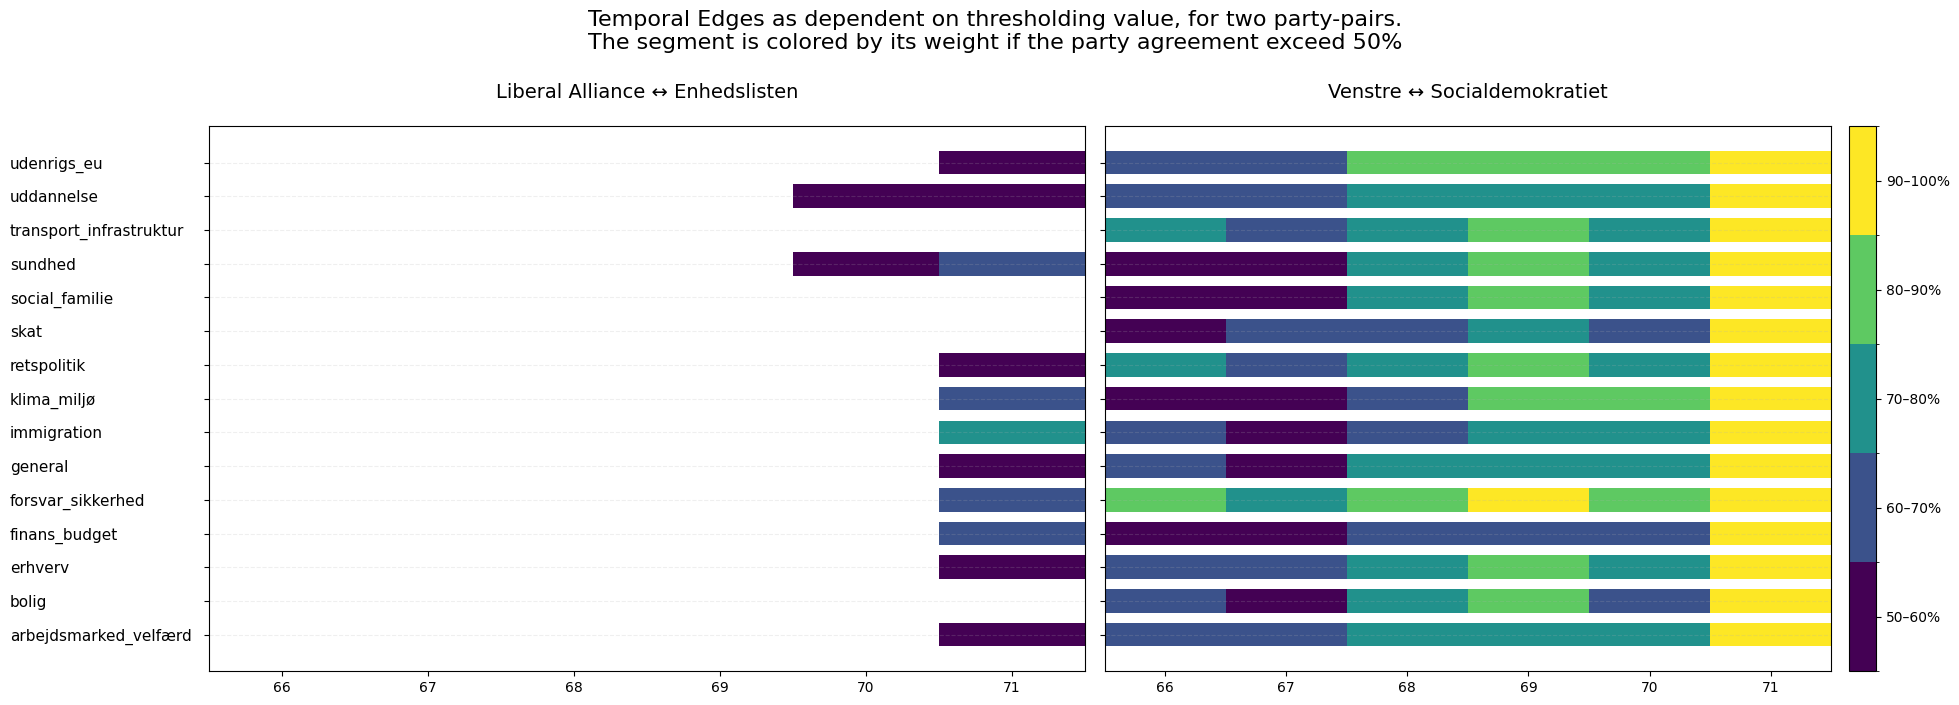

In [8]:
def plot_topic_timeline_for_pair(
    df_trad,
    party_a,
    party_b,
    weight_threshold=0.5,
    periods=(66, 67, 68, 69, 70, 71),
    cmap_name="viridis",
    ax=None,
    add_colorbar=False,
):
    df = df_trad.copy()
    parties = {party_a, party_b}

    # --- 1) Filter relevant edges --------------------------------------
    base = df[
        (df["source"].isin(parties)) &
        (df["target"].isin(parties)) &
        (df["source"] != df["target"]) &
        (df["Period"].isin(periods))
    ].copy()

    if base.empty:
        if ax is not None:
            ax.set_title(f"No data for {party_a} ↔ {party_b}")
        else:
            print("No edges for this party pair / period selection.")
        return ax

    # --- 2) Normalize direction so A–B and B–A combine ------------------
    base["src_norm"] = base[["source", "target"]].min(axis=1)
    base["tgt_norm"] = base[["source", "target"]].max(axis=1)

    # Aggregate weights per (topic, period)
    agg = (
        base
        .groupby(["topic", "Period", "src_norm", "tgt_norm"], as_index=False)
        .agg(weight=("weight", "mean"))
    )

    # --- 3) Topic positions -------------------------------------------
    topics = sorted(agg["topic"].unique())
    y_positions = {t: i for i, t in enumerate(topics)}

    # --- 4) Enforce 50% cutoff ----------------------------------------
    seg = agg[agg["weight"] >= 0.5].copy()

    if ax is None:
        fig, ax = plt.subplots(figsize=(16, 10))

    if seg.empty:
        ax.set_yticks(range(len(topics)))
        ax.set_yticklabels(topics, ha="left", fontsize=11)
        ax.tick_params(axis='y', pad=120)
        ax.set_xticks(list(periods))
        ax.set_xlim(min(periods) - 0.5, max(periods) + 0.5)
        ax.set_xlabel("Elective Periods", fontsize=12)
        ax.set_title(f"{party_a} ↔ {party_b}\nNo weights ≥ 50%", fontsize=14, pad=20)
        ax.grid(axis="y", linestyle="--", alpha=0.2)
        return ax

    # --- 5) Discrete color bins ---------------------------------------
    bins = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0000001]
    cmap = plt.get_cmap(cmap_name, 5)  # works on older Matplotlib
    norm = colors.BoundaryNorm(bins, cmap.N)

    # --- 6) Draw bars --------------------------------------------------
    for _, row in seg.sort_values(["topic", "Period"]).iterrows():
        topic = row["topic"]
        period = row["Period"]
        weight = row["weight"]
        y = y_positions[topic]

        ax.broken_barh(
            [(period - 0.5, 1.0)],
            (y - 0.35, 0.7),
            facecolors=cmap(norm(weight)),
            edgecolors=None, # "black"
            alpha = 1,
            linewidth=0.4,
        )

    # --- 7) Axis formatting -------------------------------------------
    ax.set_yticks(range(len(topics)))
    ax.set_yticklabels(topics, ha="left", fontsize=11)
    ax.tick_params(axis='y', pad=140)
    ax.set_xticks(list(periods))
    ax.set_xlim(min(periods) - 0.5, max(periods) + 0.5)
    ax.set_title(f"{party_a} ↔ {party_b}", fontsize=14, pad=20)
    ax.grid(axis="y", linestyle="--", alpha=0.2)

    # --- 8) Optional colorbar -----------------------------------------
    if add_colorbar:
        sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, pad=0.02, boundaries=bins)
        cbar.set_ticks([0.55, 0.65, 0.75, 0.85, 0.95])
        cbar.set_ticklabels(["50–60%", "60–70%", "70–80%", "80–90%", "90–100%"])
        # cbar.set_label("Agreement weight (binned)", fontsize=12)

    return ax

fig, axs = plt.subplots(1, 2, figsize=(20, 7), sharey=True)

plot_topic_timeline_for_pair(df_traditional_parties, "Liberal Alliance", "Enhedslisten", ax=axs[0])
plot_topic_timeline_for_pair(df_traditional_parties, "Venstre", "Socialdemokratiet", ax=axs[1], add_colorbar=True)

plt.suptitle(f"Temporal Edges as dependent on thresholding value, for two party-pairs.\n"
            "The segment is colored by its weight if the party agreement exceed 50%"
            , fontsize=16, y=1)
plt.tight_layout()
plt.show()


>**Figure X:** The plot shows two party pairs, and what topics they have had an agreement on (edge between) for different periods. Period 71 seems to be a period of extremely high agreement, where "Venstre" and "Socialdemokratiet" have extremely high agreement across all legislation. This makes sense as they are 2 of the 3 parties in government.

Our analysis shows that the connection between edges is very dependent on the topic, and the thresholding value. The connections can concluded to likely also relate to communities, as the first graph showed that "Enhedslisten" almost always agrees with "Radikale Venstre" and "Socialistisk Folkeparti", which can be attributed to their belonging to "rød blok", whilst "Venstre" and "Socialdemokratiet" are different "blocs" but have extremely high agreement in a period where they are in government together, which can be seen as another community.